In [3]:
import pandas as pd          
import numpy as np            
import matplotlib.pyplot as plt  
import seaborn as sns       
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler      
from sklearn.metrics import log_loss                  
import torch               
import torch.nn as nn        
from torch.utils.data import Dataset, DataLoader  
from tqdm import tqdm       
import warnings


## Step 1: Load and Explore the Data
We need to know:
- How much data do we have?
- What columns exist?
- What does the data look like?
- How is the target distributed? (Are wins balanced or does one class dominate?)

In [6]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')
print(f"Training data: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test data: {test.shape[0]} rows, {test.shape[1]} columns")
print(f"\n--- Training columns ---")
for col in train.columns:
    print(f"  - {col}")
print(f"\n--- First 3 rows of training data ---")
train.head(3)

Training data: 57477 rows, 9 columns
Test data: 3 rows, 4 columns

--- Training columns ---
  - id
  - model_a
  - model_b
  - prompt
  - response_a
  - response_b
  - winner_model_a
  - winner_model_b
  - winner_tie

--- First 3 rows of training data ---


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


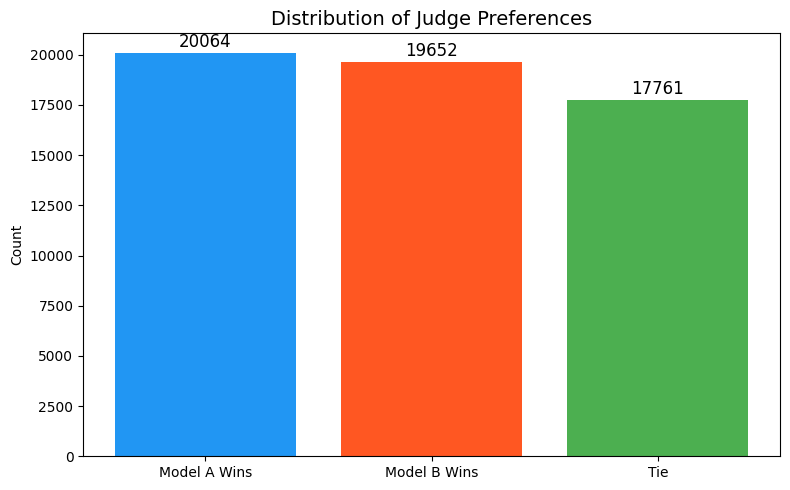

Percentages:
  Model A Wins: 34.9%
  Model B Wins: 34.2%
  Tie: 30.9%


In [ ]:
# Let's see how the judges voted - this is our TARGET (what we want to predict)
# NOTE: "Model A" and "Model B" are NOT specific models - they're just POSITIONS.
# Each row has a different pair of LLMs randomly assigned to slot A and B.
# So this chart shows POSITIONAL preference, not preference for a specific LLM.
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Count wins for each category
winner_counts = {
    'Model A Wins': train['winner_model_a'].sum(),
    'Model B Wins': train['winner_model_b'].sum(),
    'Tie': train['winner_tie'].sum()
}
bars = ax.bar(winner_counts.keys(), winner_counts.values(), 
              color=['#2196F3', '#FF5722', '#4CAF50'])
ax.set_title('Distribution of Judge Preferences (by position, not specific model)', fontsize=14)
ax.set_ylabel('Count')

# Add count labels on bars
for bar, count in zip(bars, winner_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{count}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# Print percentages
print("Percentages:")
total = sum(winner_counts.values())
for k, v in winner_counts.items():
    print(f"  {k}: {v/total*100:.1f}%")

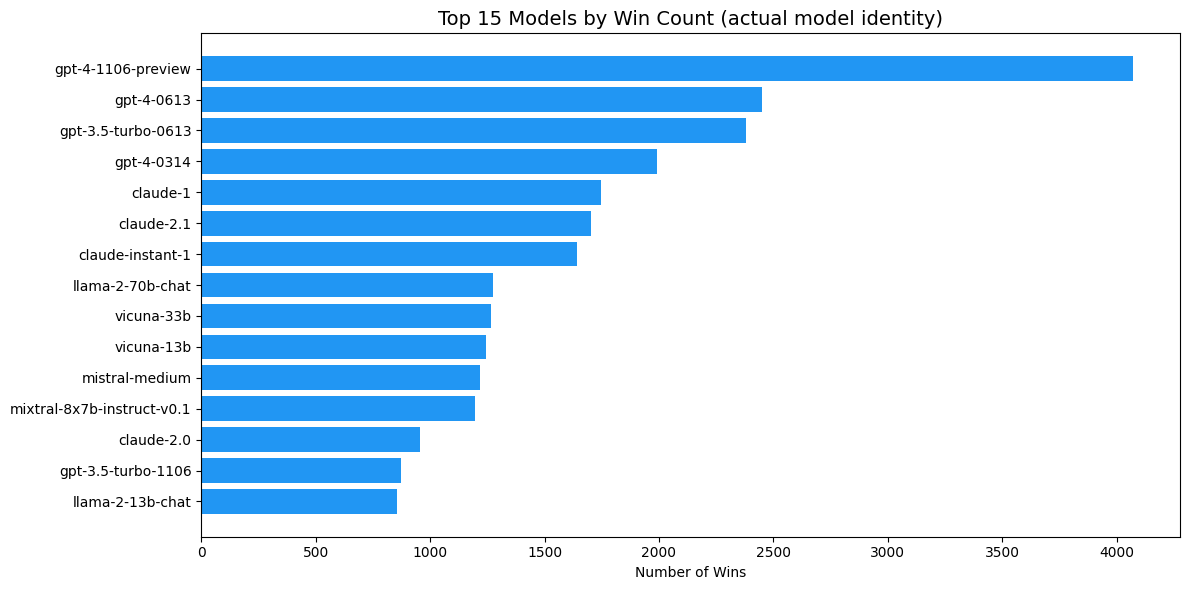


Total unique models in the dataset: 64


In [ ]:
# Count wins per actual model
model_wins = {}
# When model in slot A wins
a_wins = train[train['winner_model_a'] == 1]['model_a'].value_counts()
for model_name, count in a_wins.items():
    model_wins[model_name] = model_wins.get(model_name, 0) + count

# When model in slot B wins
b_wins = train[train['winner_model_b'] == 1]['model_b'].value_counts()
for model_name, count in b_wins.items():
    model_wins[model_name] = model_wins.get(model_name, 0) + count

# Show top 15 models by win count
top_models = sorted(model_wins.items(), key=lambda x: x[1], reverse=True)[:15]
names, counts = zip(*top_models)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
bars = ax.barh(range(len(names)), counts, color='#2196F3')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Number of Wins')
ax.set_title('Top 15 Models by Win Count (actual model identity)', fontsize=14)
ax.invert_yaxis()  # Best model at top
plt.tight_layout()
plt.show()

print(f"\nTotal unique models in the dataset: {train['model_a'].nunique()}")

## Step 2: Feature Engineering

For this first approach, we will extract **simple numerical features** from the text:
- How long is the prompt? How long are the responses?
- How many words in each?
- What is the **difference** between response A and B? (If one response is much longer, maybe the judge preferred it?)

These are simple features, but they can already capture useful patterns!

In [8]:
# FEATURE ENGINEERING: Convert text into numbers that our model can understand

def extract_features(df):
    """Extract numerical features from text columns."""
    features = pd.DataFrame()
    
    # Prompt features
    features['prompt_length'] = df['prompt'].astype(str).apply(len)
    features['prompt_word_count'] = df['prompt'].astype(str).apply(lambda x: len(x.split()))
    
    # Response A features
    features['response_a_length'] = df['response_a'].astype(str).apply(len)
    features['response_a_word_count'] = df['response_a'].astype(str).apply(lambda x: len(x.split()))
    
    # Response B features
    features['response_b_length'] = df['response_b'].astype(str).apply(len)
    features['response_b_word_count'] = df['response_b'].astype(str).apply(lambda x: len(x.split()))
    
    # Comparative features - differences between A and B
    # These are important! If response A is much longer, maybe the judge preferred it.
    features['length_diff'] = features['response_a_length'] - features['response_b_length']
    features['word_count_diff'] = features['response_a_word_count'] - features['response_b_word_count']
    features['length_ratio'] = features['response_a_length'] / (features['response_b_length'] + 1)
    features['word_ratio'] = features['response_a_word_count'] / (features['response_b_word_count'] + 1)
    
    return features

train_features = extract_features(train)
test_features = extract_features(test)

print("Features we created:")
for col in train_features.columns:
    print(f"  - {col}")
print(f"\nShape: {train_features.shape}")
train_features.head()

Features we created:
  - prompt_length
  - prompt_word_count
  - response_a_length
  - response_a_word_count
  - response_b_length
  - response_b_word_count
  - length_diff
  - word_count_diff
  - length_ratio
  - word_ratio

Shape: (57477, 10)


,prompt_length,prompt_word_count,response_a_length,response_a_word_count,response_b_length,response_b_word_count,length_diff,word_count_diff,length_ratio,word_ratio
0,165,28,4538,656,1206,204,3332,452,3.759735,3.200000
1,200,35,3114,531,3649,571,-535,-40,0.853151,0.928322
2,60,9,921,138,1835,280,-914,-142,0.501634,0.491103
3,87,18,3182,536,1562,265,1620,271,2.035829,2.015038
4,79,14,1300,230,772,122,528,108,1.681759,1.869919


## Step 3: Prepare Data for PyTorch

Before we can train, we need to:

1. **Create a target variable**: Convert the 3 binary columns (winner_model_a, winner_model_b, winner_tie) into a single column with values 0, 1, or 2
2. **Split the data**: Keep 80% for training, 20% for validation (to check if our model is overfitting)
3. **Normalize features**: Scale all numbers to a similar range (mean=0, std=1). This helps the neural network learn faster.
4. **Create PyTorch Datasets and DataLoaders**:
   - A **Dataset** tells PyTorch how to access each sample
   - A **DataLoader** feeds samples to the model in **batches** (groups). We don't feed all 57K examples at once - we split them into small groups (e.g., 256 at a time)

In [9]:
# Create our target variable
# Convert 3 binary columns into a single column: 0=Model A wins, 1=Model B wins, 2=Tie
target = np.argmax(train[['winner_model_a', 'winner_model_b', 'winner_tie']].values, axis=1)

print(f"Target classes: 0=Model A wins, 1=Model B wins, 2=Tie")
print(f"Target distribution: {dict(zip(*np.unique(target, return_counts=True)))}")

# Split into training (80%) and validation (20%) sets
# stratify=target ensures each split has the same proportion of classes
X_train, X_val, y_train, y_val = train_test_split(
    train_features.values, target, test_size=0.2, random_state=42, stratify=target
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Target classes: 0=Model A wins, 1=Model B wins, 2=Tie
Target distribution: {np.int64(0): np.int64(20064), np.int64(1): np.int64(19652), np.int64(2): np.int64(17761)}

Training set size: 45981
Validation set size: 11496


In [10]:
# NORMALIZE features: Scale all features to have mean=0 and std=1
# Why? If one feature ranges 0-10 and another 0-10000, the big one dominates.
# Normalizing puts them on equal footing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on training data (learn mean/std)
X_val_scaled = scaler.transform(X_val)            # Transform validation (use training stats!)
X_test_scaled = scaler.transform(test_features.values)  # Transform test data

# Create a PyTorch Dataset class
# This is a "recipe" that tells PyTorch how to access each data sample
class TextFeaturesDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels) if labels is not None else None
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.features[idx], self.labels[idx]
        return self.features[idx]

# Create datasets
train_dataset = TextFeaturesDataset(X_train_scaled, y_train)
val_dataset = TextFeaturesDataset(X_val_scaled, y_val)
test_dataset = TextFeaturesDataset(X_test_scaled)

# Create DataLoaders - these feed data to the model in batches
# shuffle=True for training (randomize order each epoch), False for validation/test
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Number of training batches: {len(train_loader)} (each with up to {BATCH_SIZE} samples)")
print(f"Number of validation batches: {len(val_loader)}")

Number of features: 10
Number of training batches: 180 (each with up to 256 samples)
Number of validation batches: 45


## Step 4: Build the Neural Network


Our network architecture:
```
Input (10 features) --> Hidden Layer 1 (128 neurons) --> Hidden Layer 2 (64 neurons) --> Output (3 classes)
```

Key components:
- **Linear layer**: Multiplies inputs by weights and adds a bias (like y = mx + b, but in many dimensions)
- **ReLU (activation function)**: Adds non-linearity. Without it, stacking layers would be no better than a single layer. ReLU simply says: "if the number is negative, make it 0; otherwise keep it"
- **Dropout**: During training, randomly "turns off" some neurons. This forces the network to not rely on any single neuron too much, which prevents overfitting. It is like studying with random pages of your notes hidden - you learn the material more broadly.
- **Output layer**: Produces 3 raw numbers (one per class). We later convert these to probabilities using **softmax**.

In [11]:
# Define our Neural Network
class LLMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_classes=3):
        super(LLMClassifier, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1: input features -> 128 neurons
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),               # Activation: negative values become 0
            nn.Dropout(0.3),         # Randomly turn off 30% of neurons (prevents overfitting)
            
            # Layer 2: 128 neurons -> 64 neurons
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),         # Less dropout in deeper layers
            
            # Output layer: 64 neurons -> 3 classes
            nn.Linear(hidden_size // 2, num_classes)
        )
    
    def forward(self, x):
        """Forward pass: data flows through the network."""
        return self.network(x)

# Create the model
INPUT_SIZE = X_train_scaled.shape[1]
model = LLMClassifier(INPUT_SIZE)

print("Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture:
LLMClassifier(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total trainable parameters: 9,859


## Step 5: Train the Model

Training is a loop that repeats these 4 steps for each batch of data:

1. **Forward pass**: Feed data through the network to get predictions
2. **Loss calculation**: Measure how wrong the predictions are (using **CrossEntropyLoss** - the standard loss for classification)
3. **Backward pass** (backpropagation): Calculate **gradients** - these tell us which direction to adjust each weight to reduce the error
4. **Optimizer step**: Actually update the weights (using **Adam** optimizer, which is smart about how big each adjustment should be)

One complete pass through ALL the training data is called an **epoch**. We train for multiple epochs so the model keeps improving.

We also track **validation loss** to make sure the model is truly learning and not just memorizing.

In [12]:
# Set up training
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Training on: {device}")

model = model.to(device)

# Loss function: CrossEntropyLoss is the standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam adapts the learning rate for each parameter automatically
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Scheduler: gradually reduce learning rate when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# --- TRAINING LOOP ---
NUM_EPOCHS = 50
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # === TRAINING PHASE ===
    model.train()  # Enable dropout
    epoch_train_loss = 0
    
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        
        # Step 1: Forward pass - get predictions
        outputs = model(features)
        
        # Step 2: Calculate loss - how wrong are we?
        loss = criterion(outputs, labels)
        
        # Step 3: Backward pass - calculate gradients
        optimizer.zero_grad()  # Clear old gradients first
        loss.backward()        # Calculate new gradients
        
        # Step 4: Update weights
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # === VALIDATION PHASE ===
    model.eval()  # Disable dropout
    epoch_val_loss = 0
    
    with torch.no_grad():  # No gradients needed for validation
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Reduce learning rate if validation loss plateaus
    scheduler.step(avg_val_loss)
    
    # Save the best model (lowest validation loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f}")

print(f"\nTraining complete! Best validation loss: {best_val_loss:.4f}")

Training on: mps
Epoch [ 10/50]  Train Loss: 1.0577  Val Loss: 1.0523
Epoch [ 20/50]  Train Loss: 1.0557  Val Loss: 1.0507
Epoch [ 30/50]  Train Loss: 1.0542  Val Loss: 1.0492
Epoch [ 40/50]  Train Loss: 1.0534  Val Loss: 1.0487
Epoch [ 50/50]  Train Loss: 1.0526  Val Loss: 1.0482

Training complete! Best validation loss: 1.0482


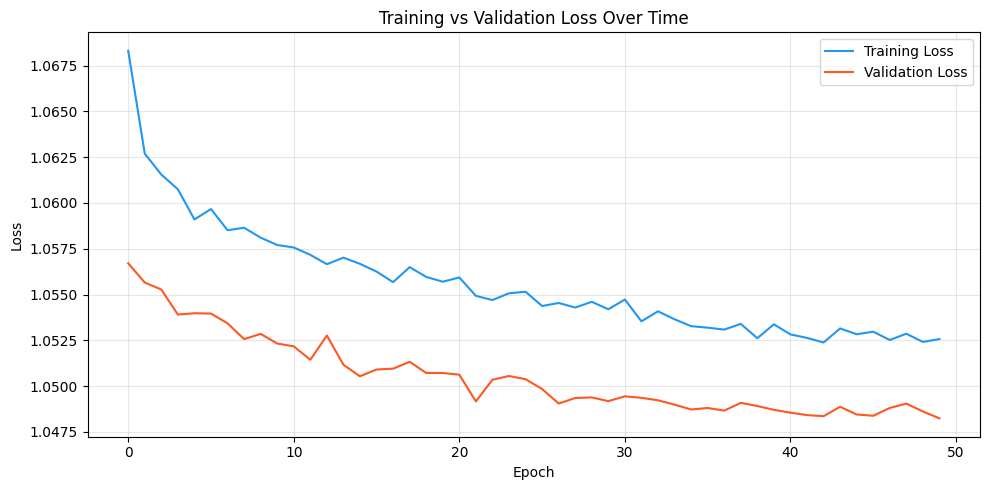

In [13]:
# Visualize the training process
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label='Training Loss', color='#2196F3')
ax.plot(val_losses, label='Validation Loss', color='#FF5722')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INTERPRETING THIS CHART:
# - Both lines going DOWN = model is learning (good!)
# - Training loss going down but validation going UP = overfitting (bad!)
# - Both lines flat = model stopped learning, might need more features or different architecture

## Step 6: Evaluate and Make Predictions

Now we load the best model (the one from the epoch with the lowest validation loss) and:
1. Check our **validation score** using **log loss** (the competition metric)
2. Generate **predictions** on the test set
3. Create a **submission file**

**Log loss** measures how good our predicted probabilities are. Lower is better.
- Perfect predictions = 0
- Random guessing (33% each class) = about 1.099

In [14]:
# Load the best model we saved during training
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
model.eval()

# --- Evaluate on validation set ---
val_predictions = []
with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        # Softmax converts raw scores into probabilities (they sum to 1)
        probabilities = torch.softmax(outputs, dim=1)
        val_predictions.append(probabilities.cpu().numpy())

val_preds = np.concatenate(val_predictions, axis=0)

# Calculate log loss (the competition metric)
from sklearn.preprocessing import label_binarize
y_val_onehot = label_binarize(y_val, classes=[0, 1, 2])

score = log_loss(y_val_onehot, val_preds)
random_guess_score = -np.log(1/3)

print(f"Our Validation Log Loss: {score:.4f}")
print(f"Random Guess Log Loss:   {random_guess_score:.4f}")
print(f"\n{'Better than random!' if score < random_guess_score else 'Worse than random - need improvement'}")

Our Validation Log Loss: 1.0482
Random Guess Log Loss:   1.0986

Better than random!


In [15]:
# --- Generate predictions on the TEST set ---
all_predictions = []
with torch.no_grad():
    for features in test_loader:
        if isinstance(features, (list, tuple)):
            features = features[0]
        features = features.to(device)
        outputs = model(features)
        probabilities = torch.softmax(outputs, dim=1)
        all_predictions.append(probabilities.cpu().numpy())

predictions = np.concatenate(all_predictions, axis=0)

# Create the submission file
submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': predictions[:, 0],
    'winner_model_b': predictions[:, 1],
    'winner_tie': predictions[:, 2]
})

submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows:")
submission.head()

Submission file created: submission.csv
Shape: (3, 4)

First 5 rows:


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.251903,0.283035,0.465062
1,211333,0.464184,0.241051,0.294765
2,1233961,0.344228,0.352873,0.302899
